CLEANING GROUP- FORGELAB DOCUMENT


1. Create a count plot for test preparation course grouped by parental level of education

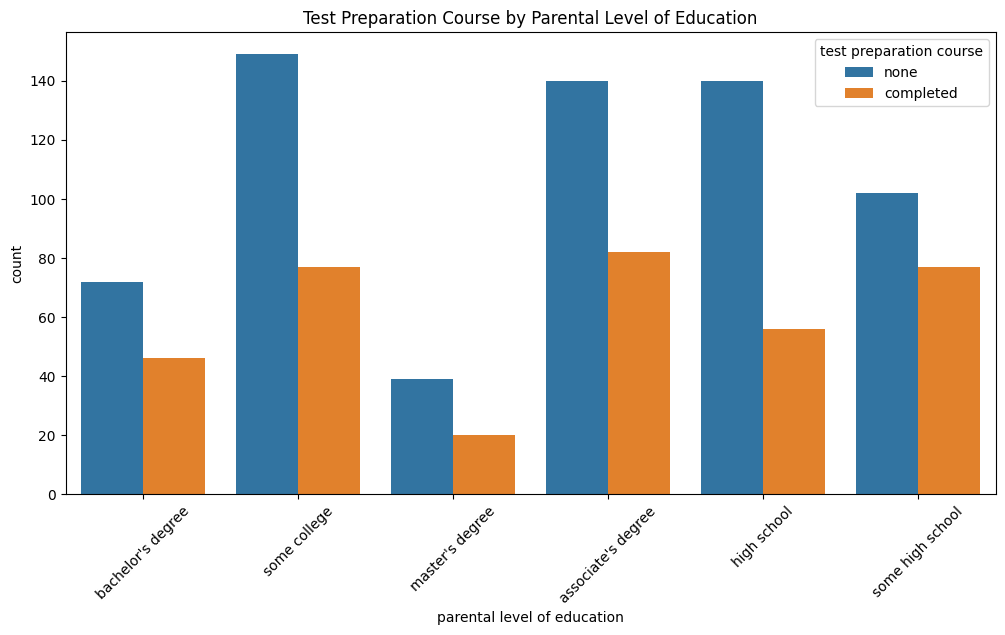

In [ ]:
#Loading the Necessary Packages
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Loading  the dataset
df = pd.read_csv('StudentsPerformance.csv')

# Create the count plot
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='parental level of education', hue='test preparation course')
plt.title('Test Preparation Course by Parental Level of Education')
plt.xticks(rotation=45)
plt.show()

2. Add two new columns Total_score and average

In [ ]:
# Create Total_score by summing math, reading, and writing scores
df['Total_score'] = df['math score'] + df['reading score'] + df['writing score']

# Create average column
df['average'] = df['Total_score'] / 3

# Display the first few rows to verify
print(df[['math score', 'reading score', 'writing score', 'Total_score', 'average']].head())

   math score  reading score  writing score  Total_score    average
0          72             72             74          218  72.666667
1          69             90             88          247  82.333333
2          90             95             93          278  92.666667
3          47             57             44          148  49.333333
4          76             78             75          229  76.333333


3. Create a new column Math_PassStatus based on math score (Pass mark is 50)

In [ ]:
# Assign 'P' for pass (>=50) and 'F' for fail (<50)
df['Math_PassStatus'] = df['math score'].apply(lambda x: 'P' if x >= 50 else 'F')

4. Create a count plot for Math_PassStatus

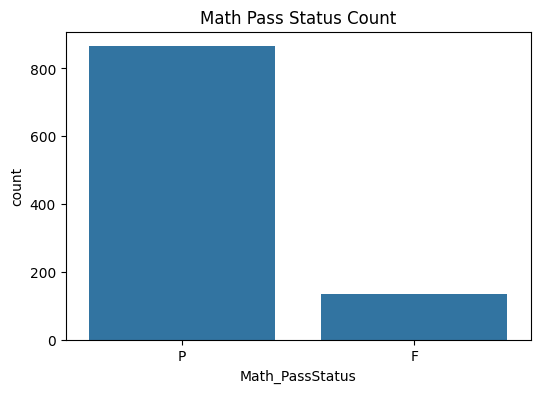

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Math_PassStatus')
plt.title('Math Pass Status Count')
plt.show()

5. Create a new column Reading_PassStatus based on reading score (Pass mark is 50)

In [ ]:
df['Reading_PassStatus'] = df['reading score'].apply(lambda x: 'P' if x >= 50 else 'F')

6. Create a new column Writing_PassStatus based on writing score (Pass mark is 50)

In [ ]:
df['Writing_PassStatus'] = df['writing score'].apply(lambda x: 'P' if x >= 50 else 'F')

7. Create a new column Overall_PassStatus
If a student has a 'P' in Math, Reading, and Writing, their overall status is 'P'. Otherwise, it is 'F'.

In [ ]:
# Check if all three pass status columns are 'P'
df['Overall_PassStatus'] = df.apply(lambda row: 'P' if (row['Math_PassStatus'] == 'P' and
                                                        row['Reading_PassStatus'] == 'P' and
                                                        row['Writing_PassStatus'] == 'P') else 'F', axis=1)

8. Create a count plot for Overall_PassStatus grouped by parental level of education

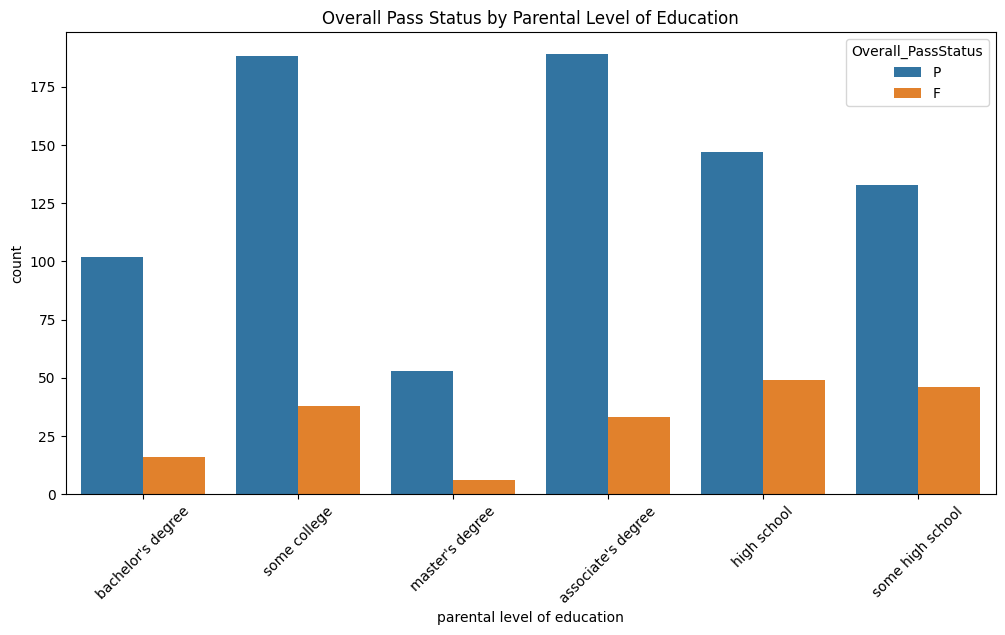

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='parental level of education', hue='Overall_PassStatus')
plt.title('Overall Pass Status by Parental Level of Education')
plt.xticks(rotation=45)
plt.show()

9. Create a new column Grade based on the given grading criteria
Criteria:

= 80: 'A'

70-79: 'B'

60-69: 'C'

50-59: 'D'

40-49: 'E'

< 40: 'F'

Note: If Overall_PassStatus is 'F', the grade should automatically be 'F'

In [ ]:
def get_grade(percentage, overall_status):
    if overall_status == 'F':
        return 'F'
    if percentage >= 80:
        return 'A'
    elif percentage >= 70:
        return 'B'
    elif percentage >= 60:
        return 'C'
    elif percentage >= 50:
        return 'D'
    elif percentage >= 40:
        return 'E'
    else:
        return 'F'

df['Grade'] = df.apply(lambda row: get_grade(row['average'], row['Overall_PassStatus']), axis=1)


10. Create a count plot for Grade sorted in alphabetical order

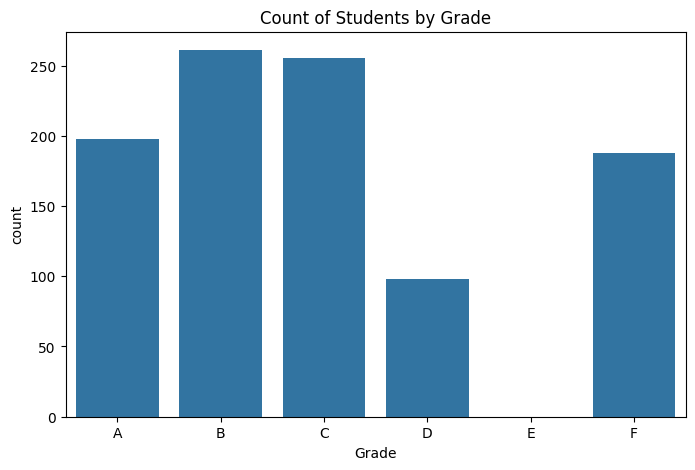

In [ ]:
plt.figure(figsize=(8, 5))
grade_order = ['A', 'B', 'C', 'D', 'E', 'F']
sns.countplot(data=df, x='Grade', order=grade_order)
plt.title('Count of Students by Grade')
plt.show()

This is the Final Block to Generate the Cleaned_data.csv

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the original dataset
df = pd.read_csv('StudentsPerformance.csv')

# 2. Add 'Total_score' and 'average'
df['Total_score'] = df['math score'] + df['reading score'] + df['writing score']
df['average'] = df['Total_score'] / 3

# 3. Add Individual Pass Statuses (Pass mark is 50)
df['Math_PassStatus'] = df['math score'].apply(lambda x: 'P' if x >= 50 else 'F')
df['Reading_PassStatus'] = df['reading score'].apply(lambda x: 'P' if x >= 50 else 'F')
df['Writing_PassStatus'] = df['writing score'].apply(lambda x: 'P' if x >= 50 else 'F')

# 4. Add 'Overall_PassStatus'
df['Overall_PassStatus'] = df.apply(lambda row: 'P' if (row['Math_PassStatus'] == 'P' and
                                                        row['Reading_PassStatus'] == 'P' and
                                                        row['Writing_PassStatus'] == 'P') else 'F', axis=1)

# 5. Add 'Grade'
def get_grade(percentage, overall_status):
    if overall_status == 'F':
        return 'F'
    if percentage >= 80:
        return 'A'
    elif percentage >= 70:
        return 'B'
    elif percentage >= 60:
        return 'C'
    elif percentage >= 50:
        return 'D'
    elif percentage >= 40:
        return 'E'
    else:
        return 'F'

df['Grade'] = df.apply(lambda row: get_grade(row['average'], row['Overall_PassStatus']), axis=1)

# ==========================================
# EXPORT THE CLEANED DATA TO CSV
# ==========================================
df.to_csv('cleaned_data.csv', index=False)
print("Data successfully saved to 'cleaned_data.csv'")

Data successfully saved to 'cleaned_data.csv'


Matthew Tasks- Checking for Empty Values

In [1]:
import pandas as pd
import numpy as np

# Sample dataset
data = {
    "Name": ["John", "Mary", "Peter", "James", None],
    "Math": [80, 75, None, 90, 65],
    "English": [70, None, 85, 88, 92],
    "Physics": [None, 78, 80, 85, 90]
}

df = pd.DataFrame(data)

# Run df.isnull().sum()
missing = df.isnull().sum()

# List columns with missing values
missing_columns = missing[missing > 0]

# Count total missing values
total_missing = df.isnull().sum().sum()

# Print results
print("Missing values per column:")
print(missing)

print("\nColumns with missing values:")
print(missing_columns)

print("\nTotal missing values:")
print(total_missing)

Missing values per column:
Name       1
Math       1
English    1
Physics    1
dtype: int64

Columns with missing values:
Name       1
Math       1
English    1
Physics    1
dtype: int64

Total missing values:
4
